# Deforestación Perú — Dataset para la U-Net

**Proyecto final MIA-07** — Detección de deforestación con U-Net.

Toma los pares **(imagen 4-band, máscara binaria)** de los notebooks 02 y 03 y arma el dataset de entrenamiento:

- Las imágenes son recortes chicos (~130×130 px), así que **redimensionamos** cada par a **128×128** (no cortamos parches: las imágenes son más chicas que 256).
- **Normalizamos** las 4 bandas Sentinel-2 (reflectancia L2A ×10000) a [0, 1].
- **Split sin data leakage**: separamos por `stac_item` (escena), no aleatorio. Polígonos de la misma escena no pueden caer en train Y test a la vez.
- Entregamos un `Dataset` de PyTorch que devuelve `(img 4×128×128, mask 1×128×128)`, con augmentation (flips) solo en train.

> Requisito: corre antes `02_descarga_sentinel2.ipynb` y `03_generar_mascaras.ipynb`.

## 1. Dependencias y almacenamiento

In [1]:
!pip install -q rasterio opencv-python-headless torch

from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/deforestacion-peru")
except ImportError:
    BASE_DIR = Path(".")

DATA_DIR      = BASE_DIR / "data"
IMG_DIR       = DATA_DIR / "sentinel_rgbn"
MASK_DIR      = DATA_DIR / "masks"
MANIFEST_PATH = DATA_DIR / "sentinel_manifest.json"
print("Imágenes:", IMG_DIR, "| Máscaras:", MASK_DIR)

Mounted at /content/drive
Imágenes: /content/drive/MyDrive/deforestacion-peru/data/sentinel_rgbn | Máscaras: /content/drive/MyDrive/deforestacion-peru/data/masks


## 2. Emparejar imágenes con máscaras

Para cada registro `ok` del manifest verificamos que existan **imagen Y máscara**. Guardamos también el `stac_item` (la escena), que usaremos para el split.

In [2]:
import json
import rasterio

manifest = json.loads(MANIFEST_PATH.read_text())

def n_bands(path):
    try:
        with rasterio.open(path) as s:
            return s.count
    except Exception:
        return 0

pairs = []
n_drop_band = 0
for rec in manifest.values():
    if rec.get("status") != "ok":
        continue
    img = Path(rec["path"])
    msk = MASK_DIR / f"mask_{rec['row_id']}.tif"
    if not (img.exists() and msk.exists()):
        continue
    if n_bands(img) != 4:           # descarta .tif viejos de 3 bandas
        n_drop_band += 1
        continue
    pairs.append({
        "row_id": rec["row_id"],
        "img": str(img),
        "mask": str(msk),
        "scene": rec.get("stac_item", rec["row_id"]),  # escena para el split
    })

from collections import Counter
print(f"Pares: {len(pairs)} | Escenas únicas: {len(set(p['scene'] for p in pairs))}")
if n_drop_band:
    print(f"  ⚠️ descartados por no tener 4 bandas: {n_drop_band} (re-corre 02 si son muchos)")

# Nota: el thinning por overlap ahora vive en 02 (filtra antes de descargar),
# así que el manifest ya viene sin solapes >20%. Aquí solo curamos y partimos.

# --- FILTRO CURADO (seleccion_keep_fixed.json del curador web) --------------
# Curaste los pares a mano en website/index.html (revisas Sentinel real vs
# Google + máscara, marcas Keep/Reject) y exportaste "Export keep". El export
# se llama seleccion_keep.json; lo renombraste a seleccion_keep_fixed.json y lo
# pusiste en data/train/ (MISMO archivo que usa el notebook 03 para filtrar).
# Aquí nos quedamos solo con los row_id "keep". Sin archivo -> usa todo.
SEL_PATH = DATA_DIR / "train" / "seleccion_keep_fixed.json"
if SEL_PATH.exists():
    keep_ids = {str(r["row_id"]) for r in json.loads(SEL_PATH.read_text())}
    antes = len(pairs)
    pairs = [p for p in pairs if str(p["row_id"]) in keep_ids]
    print(f"Curado: {len(pairs)}/{antes} pares tras seleccion_keep_fixed.json "
          f"({len(keep_ids)} row_id keep)")
else:
    print("Sin seleccion_keep_fixed.json -> uso todos los pares (curado opcional)")

scenes = sorted({p["scene"] for p in pairs})
por_escena = Counter(p["scene"] for p in pairs)
print(f"\nPares finales: {len(pairs)} | Escenas únicas: {len(scenes)}")
print("Imágenes por escena (top 10):")
for sc, cnt in por_escena.most_common(10):
    print(f"  {cnt:4d}  {sc}")

Pares: 624 | Escenas únicas: 88
  ⚠️ descartados por no tener 4 bandas: 2 (re-corre 02 si son muchos)
Curado: 624/624 pares tras seleccion_keep_fixed.json (626 row_id keep)

Pares finales: 624 | Escenas únicas: 88
Imágenes por escena (top 10):
    31  S2B_18MWS_20170824_0_L2A
    29  S2A_18LZL_20180907_0_L2A
    29  S2B_18MVS_20171212_0_L2A
    26  S2A_19LCG_20180828_1_L2A
    25  S2B_18LVQ_20180809_0_L2A
    24  S2A_19LCF_20180619_0_L2A
    23  S2B_18MVS_20180908_0_L2A
    22  S2A_19LCF_20180907_0_L2A
    20  S2B_18LVR_20171212_0_L2A
    19  S2B_18LVR_20180809_0_L2A


## 3. Split por escena, balanceado por número de imágenes

Repartimos las **escenas** en train/val/test (~70/15/15), pero balanceando por **número de imágenes**, no por número de escenas. Como las escenas tienen tamaños muy distintos, repartir por conteo de escenas dejaba el test en ~6% en vez de 15%.

Usamos un **greedy**: escena más grande primero, cada una va al split con mayor déficit frente a su cupo. Dos recortes de la misma escena Sentinel-2 nunca quedan repartidos entre train y test → **sin leakage entre escenas** (esto bloquea el leakage cuando los recortes que se enciman comparten escena; polígonos del mismo lugar pero de fechas distintas son escenas distintas y es otro tema menor).

El split es **determinista** (escenas ordenadas por tamaño con desempate por nombre), así que es reproducible sin semilla.

In [3]:
# Split por escena, balanceado por NÚMERO DE IMÁGENES (no por número de escenas).
# Repartir escenas 70/15/15 por conteo de escenas daba splits desbalanceados
# (escenas de tamaños muy distintos): test salía ~6% en vez de 15%.
#
# Greedy: ordenamos las escenas de mayor a menor (desempate por nombre, así es
# determinista) y vamos asignando cada escena al split con mayor déficit frente
# a su cupo objetivo. Tras el thinning ninguna escena domina (top ~30), así que
# sale ~70/15/15 por imágenes. Las escenas no se parten entre splits -> sin
# leakage entre escenas.
N = len(pairs)
targets = {"train": 0.70 * N, "val": 0.15 * N, "test": 0.15 * N}
cur = {"train": 0, "val": 0, "test": 0}
scene_split = {}

# tamaño por escena, ordenado: más grande primero, desempate alfabético (determinista)
tam = Counter(p["scene"] for p in pairs)
for sc in sorted(scenes, key=lambda s: (-tam[s], s)):
    k = max(cur, key=lambda s: targets[s] - cur[s])   # split con mayor déficit
    scene_split[sc] = k
    cur[k] += tam[sc]

for p in pairs:
    p["split"] = scene_split[p["scene"]]

c = Counter(p["split"] for p in pairs)
n_sc = Counter(scene_split.values())
print(f"Escenas: train={n_sc['train']} val={n_sc['val']} test={n_sc['test']}")
print(f"Imágenes: train={c['train']} val={c['val']} test={c['test']} "
      f"-> {100*c['train']//N}/{100*c['val']//N}/{100*c['test']//N} %")

Escenas: train=40 val=24 test=24
Imágenes: train=437 val=94 test=93 -> 70/15/14 %


## 4. Dataset de PyTorch

Cada item:
- Lee la imagen 4-band y la normaliza dividiendo por 10000 (reflectancia L2A → [0, 1], recortada).
- Lee la máscara binaria.
- Redimensiona ambos a **128×128**: imagen con interpolación bilineal, máscara con vecino más cercano (no inventa valores intermedios).
- En `train`, aplica flips horizontales/verticales aleatorios (augmentation barata y válida para imágenes satelitales).

In [4]:
import numpy as np
import rasterio
import cv2
import torch
from torch.utils.data import Dataset, DataLoader

SIZE = 128

class DeforestDataset(Dataset):
    def __init__(self, items, size=SIZE, augment=False):
        self.items = items
        self.size = size
        self.augment = augment

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        it = self.items[i]
        with rasterio.open(it["img"]) as src:
            img = src.read().astype("float32")          # (4, H, W)
        with rasterio.open(it["mask"]) as src:
            mask = src.read(1).astype("float32")         # (H, W)

        # normalizar reflectancia L2A -> [0,1]
        img = np.clip(img / 10000.0, 0, 1)

        # (4,H,W) -> (H,W,4) para cv2, redimensionar, volver a (4,H,W)
        img = np.transpose(img, (1, 2, 0))
        img = cv2.resize(img, (self.size, self.size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.size, self.size), interpolation=cv2.INTER_NEAREST)

        if self.augment:
            if np.random.rand() < 0.5:
                img = img[:, ::-1, :].copy();  mask = mask[:, ::-1].copy()   # flip horizontal
            if np.random.rand() < 0.5:
                img = img[::-1, :, :].copy();  mask = mask[::-1, :].copy()   # flip vertical

        # np.transpose devuelve un view no contiguo; ascontiguousarray evita el
        # error "Trying to resize storage that is not resizable" en el collate.
        img = torch.from_numpy(np.ascontiguousarray(np.transpose(img, (2, 0, 1))))  # (4,128,128)
        mask = torch.from_numpy(np.ascontiguousarray(mask)).unsqueeze(0)            # (1,128,128)
        return img, mask

def make_loader(split, batch_size=16, augment=False, shuffle=False):
    items = [p for p in pairs if p["split"] == split]
    ds = DeforestDataset(items, augment=augment)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=2)

train_loader = make_loader("train", augment=True, shuffle=True)
val_loader   = make_loader("val")
test_loader  = make_loader("test")

xb, yb = next(iter(train_loader))
print("batch imagen:", tuple(xb.shape), xb.dtype, "| rango:", float(xb.min()), float(xb.max()))
print("batch máscara:", tuple(yb.shape), yb.dtype, "| valores:", torch.unique(yb).tolist())
print("% píxeles deforestados en el batch:", round(100 * float(yb.mean()), 2))

batch imagen: (16, 4, 128, 128) torch.float32 | rango: 9.999999747378752e-05 0.5706073045730591
batch máscara: (16, 1, 128, 128) torch.float32 | valores: [0.0, 1.0]
% píxeles deforestados en el batch: 2.91


## 5. Verificación visual de un batch

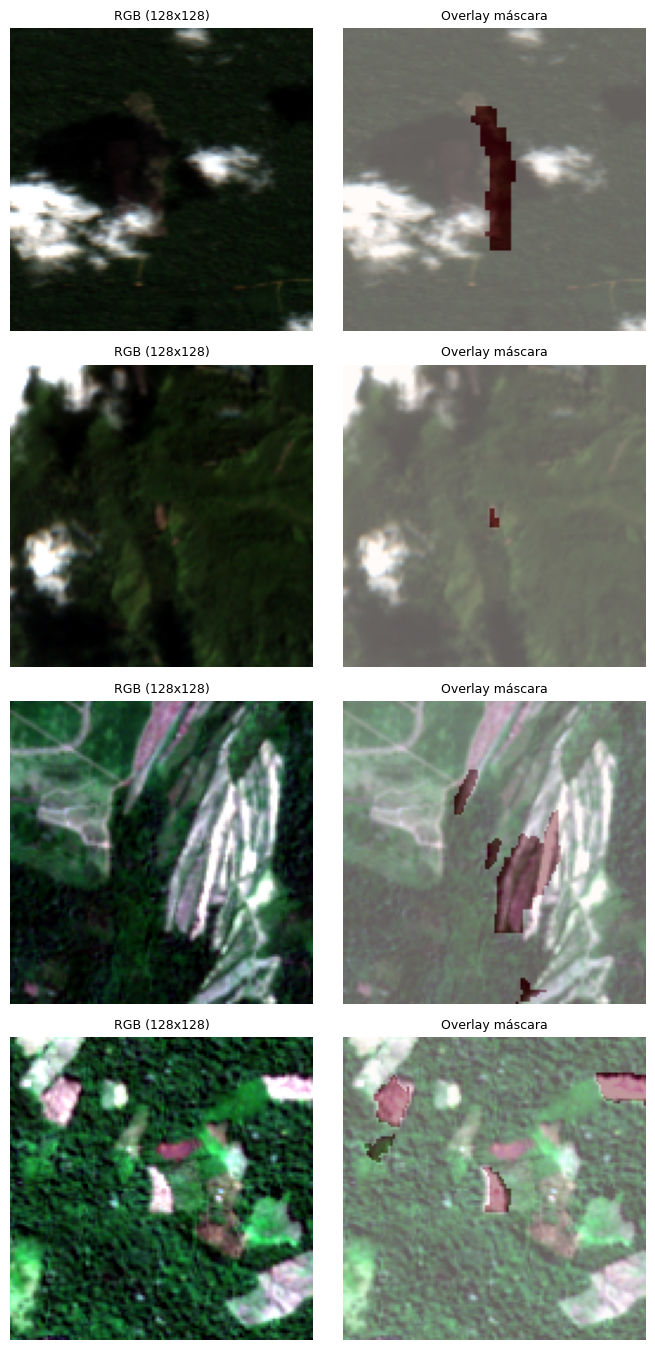

In [5]:
import matplotlib.pyplot as plt

def stretch(a, lo=2, hi=98):
    a = a.astype("float32"); pl, ph = np.percentile(a, [lo, hi])
    return np.clip((a - pl) / (ph - pl + 1e-6), 0, 1)

xb, yb = next(iter(train_loader))
k = min(4, xb.shape[0])
fig, axes = plt.subplots(k, 2, figsize=(7, 3.4 * k))
axes = np.atleast_2d(axes)
for row, img, mask in zip(axes, xb[:k], yb[:k]):
    arr = img.numpy()
    rgb = np.dstack([stretch(arr[c]) for c in range(3)])
    row[0].imshow(rgb); row[0].set_title("RGB (128x128)", fontsize=9)
    row[1].imshow(rgb); row[1].imshow(mask[0].numpy(), cmap="Reds", alpha=0.4, vmin=0, vmax=1)
    row[1].set_title("Overlay máscara", fontsize=9)
    for a in row: a.axis("off")
plt.tight_layout(); plt.savefig(str(DATA_DIR / "dataset_batch_muestra.png"), dpi=110, bbox_inches="tight"); plt.show()

## 6. Guardar el split (reproducible)

Guardamos la lista de pares con su split en un JSON. El notebook de entrenamiento (`05_modelo_unet.ipynb`) lo lee y reconstruye los mismos `DataLoader` sin re-calcular el split.

In [6]:
SPLIT_PATH = DATA_DIR / "train" / "dataset_split.json"
SPLIT_PATH.parent.mkdir(parents=True, exist_ok=True)
SPLIT_PATH.write_text(json.dumps(pairs, indent=1, ensure_ascii=False))
print(f"Split guardado en: {SPLIT_PATH}")
print(f"Total pares: {len(pairs)} | train/val/test = {c['train']}/{c['val']}/{c['test']}")

Split guardado en: /content/drive/MyDrive/deforestacion-peru/data/train/dataset_split.json
Total pares: 624 | train/val/test = 437/94/93


## 7. Próximos pasos

Dataset listo: pares 4-band normalizados a 128×128, split por escena sin leakage.

- `05_modelo_unet.ipynb`: entrenar la U-Net. Usa **Dice + BCE** como loss (la deforestación es ~6% de los píxeles, así que accuracy engaña). Evalúa con **IoU / F1 sobre la clase deforestación** en el set de test.
- Considera agregar **NDVI** como 5ta banda de entrada — separa bosque vivo de suelo desnudo y suele ayudar.